<a href="https://colab.research.google.com/github/sheriannmclarty/DATA620_WebAnalytics_SheriannMc/blob/main/Project1_Brooklyn_Commuting_skm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 1: Centrality Measures in the Brooklyn Commuting Network
**Course:** DATA 620 - Web Analytics  
**Student:** Sheriann McLarty  
**GitHub Repository:** [DATA620_WebAnalytics_SheriannMc](https://github.com/sheriannmclarty/DATA620_WebAnalytics_SheriannMc)  
**Dataset:** U.S. Census Bureau LEHD LODES OD Files (2021) + ACS 5-Year S1701 Poverty Data  

---

## Research Question
Do high-poverty and lower-poverty census tracts in Brooklyn (Kings County, NY) differ in their in-degree centrality, out-degree centrality, or eigenvector centrality within the internal commuting network? Degree centrality here reflects the **number of distinct tract-to-tract commuting links**, not total commuter volume. Weighted in/out-strength (total commuter flow volume) is computed alongside as a complementary measure.

## Hypothesis
Tracts that function as job destination hubs will be disproportionately lower-poverty tracts, showing higher in-degree centrality and eigenvector centrality. High-poverty tracts are expected to be more peripheral with lower in-degree and eigenvector centrality, reflecting structural disconnection from Brooklyn's commuting core.

---

## Network Definition
| Element | Detail |
|---|---|
| **Nodes** | Census tracts in Kings County, NY (FIPS 36047) |
| **Edges** | Directed edge: home tract -> work tract |
| **Edge weight** | Total commuters (LODES S000 field) |
| **Node attribute** | Poverty category: High Poverty (>=20%) vs Lower Poverty (<20%) |
| **Graph type** | Directed, weighted |

In [1]:
import pandas as pd
import requests
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import numpy as np
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
LODES_URL = 'https://lehd.ces.census.gov/data/lodes/LODES8/ny/od/ny_od_main_JT00_2021.csv.gz'

print('Downloading LODES OD file (this may take 1-2 minutes)...')
od = pd.read_csv(LODES_URL, compression='gzip', dtype={'h_geocode': str, 'w_geocode': str})
print(f'LODES OD loaded: {od.shape[0]:,} rows, {od.shape[1]} columns')

LODES OD loaded: 7,144,618 rows, 13 columns


In [3]:
XWALK_URL = 'https://lehd.ces.census.gov/data/lodes/LODES8/ny/ny_xwalk.csv.gz'

print('Downloading geography crosswalk...')
xwalk = pd.read_csv(XWALK_URL, compression='gzip',
                    dtype=str, usecols=['tabblk2020', 'trct', 'cty'])
xwalk = xwalk.rename(columns={'tabblk2020': 'geocode', 'trct': 'tract', 'cty': 'county'})
print(f'Crosswalk loaded: {xwalk.shape[0]:,} rows')

Crosswalk loaded: 288,819 rows


In [4]:
KINGS_FIPS = '36047'

kings_blocks = xwalk[xwalk['county'] == KINGS_FIPS][['geocode', 'tract']].copy()
block_to_tract = kings_blocks.set_index('geocode')['tract'].to_dict()
print(f'Kings County census blocks: {len(kings_blocks):,}')

Kings County census blocks: 9,855


In [5]:
od['home_tract'] = od['h_geocode'].map(block_to_tract)
od['work_tract'] = od['w_geocode'].map(block_to_tract)

od_kings = od.dropna(subset=['home_tract', 'work_tract']).copy()
print(f'Brooklyn-internal OD flows (block level): {len(od_kings):,}')

tract_od = (od_kings
            .groupby(['home_tract', 'work_tract'])['S000']
            .sum()
            .reset_index()
            .rename(columns={'S000': 'weight'}))

print(f'Tract-to-tract edges: {len(tract_od):,}')

Brooklyn-internal OD flows (block level): 338,900
Tract-to-tract edges: 153,190


In [6]:
ACS_URL = (
    'https://api.census.gov/data/2021/acs/acs5/subject'
    '?get=NAME,S1701_C03_001E'
    '&for=tract:*'
    '&in=state:36%20county:047'
)

resp = requests.get(ACS_URL)
resp.raise_for_status()
acs_raw = resp.json()
acs_df = pd.DataFrame(acs_raw[1:], columns=acs_raw[0])

acs_df['tract_fips'] = acs_df['state'] + acs_df['county'] + acs_df['tract']
acs_df['poverty_rate'] = pd.to_numeric(acs_df['S1701_C03_001E'], errors='coerce')
acs_df.loc[acs_df['poverty_rate'] < 0, 'poverty_rate'] = float('nan')
acs_df['poverty_category'] = acs_df['poverty_rate'].apply(
    lambda x: 'High Poverty' if pd.notna(x) and x >= 20 else
              ('Lower Poverty' if pd.notna(x) else 'Unknown')
)

print(f'ACS tracts: {len(acs_df)}')
print(acs_df['poverty_category'].value_counts())

ACS tracts: 805
poverty_category
Lower Poverty    525
High Poverty     252
Unknown           28
Name: count, dtype: int64


In [7]:
G = nx.from_pandas_edgelist(
    tract_od,
    source='home_tract',
    target='work_tract',
    edge_attr='weight',
    create_using=nx.DiGraph()
)

poverty_lookup = acs_df.set_index('tract_fips')['poverty_category'].to_dict()
poverty_rate_lookup = acs_df.set_index('tract_fips')['poverty_rate'].to_dict()
nx.set_node_attributes(G, poverty_lookup, name='poverty_category')
nx.set_node_attributes(G, poverty_rate_lookup, name='poverty_rate')

print(f'Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')
print('Poverty category distribution:', Counter([G.nodes[n].get('poverty_category', 'Unknown') for n in G.nodes]))

Graph: 804 nodes, 153190 edges
Poverty category distribution: Counter({'Lower Poverty': 525, 'High Poverty': 252, 'Unknown': 27})


In [8]:
# Source: NYC Department of City Planning, 2020 Census Tract to NTA Relationships
# The file maps every NYC census tract to an NTA code and NTA name (neighborhood)
# We filter to Brooklyn (BoroName == 'Brooklyn') and build a lookup dict

NTA_URL = (
    'https://www1.nyc.gov/assets/planning/download/office/planning-level/'
    'nyc-population/census2020/nyc2020census_tract_nta_cdta_relationships.xlsx'
)

try:
    nta_raw = pd.read_excel(NTA_URL)
    print(f'NTA crosswalk loaded from DCP Excel: {len(nta_raw)} rows')
    # Normalize column names to lowercase for safety
    nta_raw.columns = [c.strip().lower() for c in nta_raw.columns]

    # Identify the key columns: GeoID (tract FIPS), NTAName, BoroName
    # DCP file uses: geoid, ntaname, boroname (or GeoID, NTAName, BoroName)
    bk = nta_raw[nta_raw['boroname'].str.strip().str.lower() == 'brooklyn'].copy()

    # GeoID in DCP file is 11-digit string (e.g., '36047000100')
    bk['geoid'] = bk['geoid'].astype(str).str.zfill(11)
    tract_to_nta = bk.set_index('geoid')['ntaname'].to_dict()
    print(f'Brooklyn tracts mapped: {len(tract_to_nta)}')

except Exception as e:
    print(f'DCP Excel URL failed ({e}). Trying Socrata API fallback...')
    # Fallback: NYC Open Data Socrata API for the same dataset (ID: hm78-6dwm)
    SOCRATA_URL = 'https://data.cityofnewyork.us/resource/hm78-6dwm.csv?$limit=5000'
    nta_raw = pd.read_csv(SOCRATA_URL, dtype=str)
    nta_raw.columns = [c.strip().lower() for c in nta_raw.columns]
    bk = nta_raw[nta_raw['boroname'].str.strip().str.lower() == 'brooklyn'].copy()
    bk['geoid'] = bk['geoid'].astype(str).str.zfill(11)
    tract_to_nta = bk.set_index('geoid')['ntaname'].to_dict()
    print(f'Brooklyn tracts mapped via Socrata: {len(tract_to_nta)}')

# Preview the neighborhood names we will be using
sample = list(tract_to_nta.items())[:8]
print('\nSample tract -> neighborhood:')
for fips, name in sample:
    print(f'  {fips} -> {name}')

NTA crosswalk loaded from DCP Excel: 2327 rows
Brooklyn tracts mapped: 805

Sample tract -> neighborhood:
  36047049900 -> Greenpoint
  36047056100 -> Greenpoint
  36047056301 -> Greenpoint
  36047056302 -> Greenpoint
  36047056500 -> Greenpoint
  36047056900 -> Greenpoint
  36047057100 -> Greenpoint
  36047057300 -> Greenpoint


In [9]:
n = G.number_of_nodes()
e = G.number_of_edges()
density = nx.density(G)
lwcc = max(nx.weakly_connected_components(G), key=len)
G_lwcc = G.subgraph(lwcc).copy()
total_weight = sum(w for _, _, w in G.edges(data='weight'))

print('=== Graph Descriptives ===')
print(f'Nodes:                 {n}')
print(f'Edges:                 {e}')
print(f'Density:               {density:.4f}')
print(f'Weakly connected:      {nx.is_weakly_connected(G)}')
print(f'Strongly connected:    {nx.is_strongly_connected(G)}')
print(f'Nodes in LWCC:         {G_lwcc.number_of_nodes()}')
print(f'Total commuters:       {total_weight:,.0f}')
print()
print(f'Note: Density of {density:.4f} is relatively high for a directed network of this size.')
print('A dense internal commuting structure compresses centrality scores across all tracts,')
print('which may reduce the ability to detect statistically significant group differences.')

=== Graph Descriptives ===
Nodes:                 804
Edges:                 153190
Density:               0.2373
Weakly connected:      True
Strongly connected:    False
Nodes in LWCC:         804
Total commuters:       396,195

Note: Density of 0.2373 is relatively high for a directed network of this size.
A dense internal commuting structure compresses centrality scores across all tracts,
which may reduce the ability to detect statistically significant group differences.


In [10]:
# Also attach neighborhood name from the NTA crosswalk

in_deg = nx.in_degree_centrality(G)
out_deg = nx.out_degree_centrality(G)

in_strength = {n: sum(d['weight'] for _, _, d in G.in_edges(n, data=True)) for n in G.nodes()}
out_strength = {n: sum(d['weight'] for _, _, d in G.out_edges(n, data=True)) for n in G.nodes()}

nx.set_node_attributes(G, in_deg, name='in_degree_centrality')
nx.set_node_attributes(G, out_deg, name='out_degree_centrality')
nx.set_node_attributes(G, in_strength, name='in_strength')
nx.set_node_attributes(G, out_strength, name='out_strength')

node_df = pd.DataFrame({
    'tract': list(G.nodes()),
    'poverty_category': [G.nodes[n].get('poverty_category', 'Unknown') for n in G.nodes()],
    'poverty_rate': [G.nodes[n].get('poverty_rate', float('nan')) for n in G.nodes()],
    'in_degree_centrality': [in_deg[n] for n in G.nodes()],
    'out_degree_centrality': [out_deg[n] for n in G.nodes()],
    'in_strength': [in_strength[n] for n in G.nodes()],
    'out_strength': [out_strength[n] for n in G.nodes()],
})

# Attach neighborhood name from NTA crosswalk
node_df['neighborhood'] = node_df['tract'].map(tract_to_nta).fillna('Unknown')

print(f'node_df shape: {node_df.shape}')
print(f'Tracts with neighborhood name: {(node_df["neighborhood"] != "Unknown").sum()}')
print()
print('Sample (tract | neighborhood | poverty):')
print(node_df[node_df['neighborhood'] != 'Unknown']
      [['tract', 'neighborhood', 'poverty_category', 'in_degree_centrality']]
      .head(8).to_string(index=False))
print()
print('Degree centrality summary by poverty category:')
node_df.groupby('poverty_category')[['in_degree_centrality', 'out_degree_centrality',
                                     'in_strength', 'out_strength']].describe().round(2)

node_df shape: (804, 8)
Tracts with neighborhood name: 804

Sample (tract | neighborhood | poverty):
      tract                        neighborhood poverty_category  in_degree_centrality
36047000100                    Brooklyn Heights    Lower Poverty              0.222914
36047000200                  Sunset Park (West)     High Poverty              0.738481
36047000301                    Brooklyn Heights    Lower Poverty              0.300125
36047000501                    Brooklyn Heights    Lower Poverty              0.175592
36047000502                    Brooklyn Heights    Lower Poverty              0.315068
36047000700                    Brooklyn Heights    Lower Poverty              0.215442
36047000900                    Brooklyn Heights    Lower Poverty              0.916563
36047001100 Downtown Brooklyn-DUMBO-Boerum Hill    Lower Poverty              0.975093

Degree centrality summary by poverty category:


in_degree_centrality                                          \
                                count  mean   std  min  25%   50%   75%   max   
poverty_category                                                                
High Poverty                    252.0  0.25  0.20  0.0  0.1  0.19  0.32  0.90   
Lower Poverty                   525.0  0.23  0.19  0.0  0.1  0.17  0.31  0.98   
Unknown                          27.0  0.23  0.29  0.0  0.0  0.06  0.39  0.82   

                 out_degree_centrality        ... in_strength           \
                                 count  mean  ...         75%      max   
poverty_category                              ...                        
High Poverty                     252.0  0.25  ...       585.0   4990.0   
Lower Poverty                    525.0  0.24  ...       464.0  19107.0   
Unknown                           27.0  0.08  ...       507.0   3225.0   

                 out_strength                                                \
                        count    mean     std    min     25%    50%     75%   
poverty_category                                                              
High Poverty            252.0  548.77  212.08  114.0  397.75  509.0  666.75   
Lower Poverty           525.0  487.70  214.15   79.0  345.00  430.0  585.00   
Unknown                  27.0   69.00   17.60   36.0   51.50   75.0   84.00   

                          
                     max  
poverty_category          
High Poverty      1282.0  
Lower Poverty     1466.0  
Unknown             93.0  

[3 rows x 32 columns]

In [11]:
# Eigenvector centrality on LWCC
# Fallback to undirected if directed EVC does not converge
evc_method = 'directed'

try:
    evc = nx.eigenvector_centrality(G_lwcc, max_iter=1000, tol=1e-4, weight='weight')
    print('EVC converged on directed LWCC.')
except nx.PowerIterationFailedConvergence:
    print('Directed EVC did not converge. Using undirected projection (robustness fallback).')
    G_undirected = G_lwcc.to_undirected()
    evc = nx.eigenvector_centrality(G_undirected, max_iter=1000, tol=1e-4, weight='weight')
    evc_method = 'undirected (fallback)'
    print('Undirected EVC converged.')

print(f'EVC method: {evc_method}')
nx.set_node_attributes(G, evc, name='eigenvector_centrality')
node_df['eigenvector_centrality'] = node_df['tract'].map(evc)

print('Eigenvector centrality by poverty category:')
node_df.groupby('poverty_category')['eigenvector_centrality'].describe().round(4)

EVC converged on directed LWCC.
EVC method: directed
Eigenvector centrality by poverty category:


,count,mean,std,min,25%,50%,75%,max
poverty_category,,,,,,,,
High Poverty,252.0,0.0204,0.0488,0.0,0.0016,0.0041,0.0137,0.4655
Lower Poverty,525.0,0.0102,0.0209,0.0,0.0019,0.0042,0.0096,0.2981
Unknown,27.0,0.0114,0.0206,0.0,0.0000,0.0014,0.0106,0.0811


In [12]:
high = node_df[node_df['poverty_category'] == 'High Poverty']
lower = node_df[node_df['poverty_category'] == 'Lower Poverty']

metrics = [
    ('in_degree_centrality',  'In-Degree Centrality'),
    ('out_degree_centrality', 'Out-Degree Centrality'),
    ('eigenvector_centrality','Eigenvector Centrality'),
    ('in_strength',           'Weighted In-Strength'),
    ('out_strength',          'Weighted Out-Strength'),
]

print('=== Mann-Whitney U Test Results ===')
print(f'{"Metric":<30} {"U statistic":>15} {"p-value":>12} {"Significant":>12}')
print('-' * 72)

results = {}
for col, label in metrics:
    h_vals = high[col].dropna()
    l_vals = lower[col].dropna()
    if len(h_vals) > 0 and len(l_vals) > 0:
        u_stat, p_val = stats.mannwhitneyu(h_vals, l_vals, alternative='two-sided')
        sig = 'YES' if p_val < 0.05 else 'NO'
        results[col] = {'u': u_stat, 'p': p_val, 'sig': sig}
        print(f'{label:<30} {u_stat:>15.1f} {p_val:>12.4f} {sig:>12}')

=== Mann-Whitney U Test Results ===
Metric                             U statistic      p-value  Significant
------------------------------------------------------------------------
In-Degree Centrality                   68379.5       0.4466           NO
Out-Degree Centrality                  72977.5       0.0197          YES
Eigenvector Centrality                 68224.0       0.4790           NO
Weighted In-Strength                   68873.5       0.3525           NO
Weighted Out-Strength                  79578.5       0.0000          YES


---
## Visual Strategy
Multiple charts are included because each answers a different part of the question. The boxplots compare the two poverty groups directly. The scatterplot checks whether the pattern holds across the full poverty-rate range. The neighborhood bar chart connects tract-level results back to recognizable places in Brooklyn.

**Color encoding is consistent across all figures:** deep red = High Poverty, forest green = Lower Poverty.

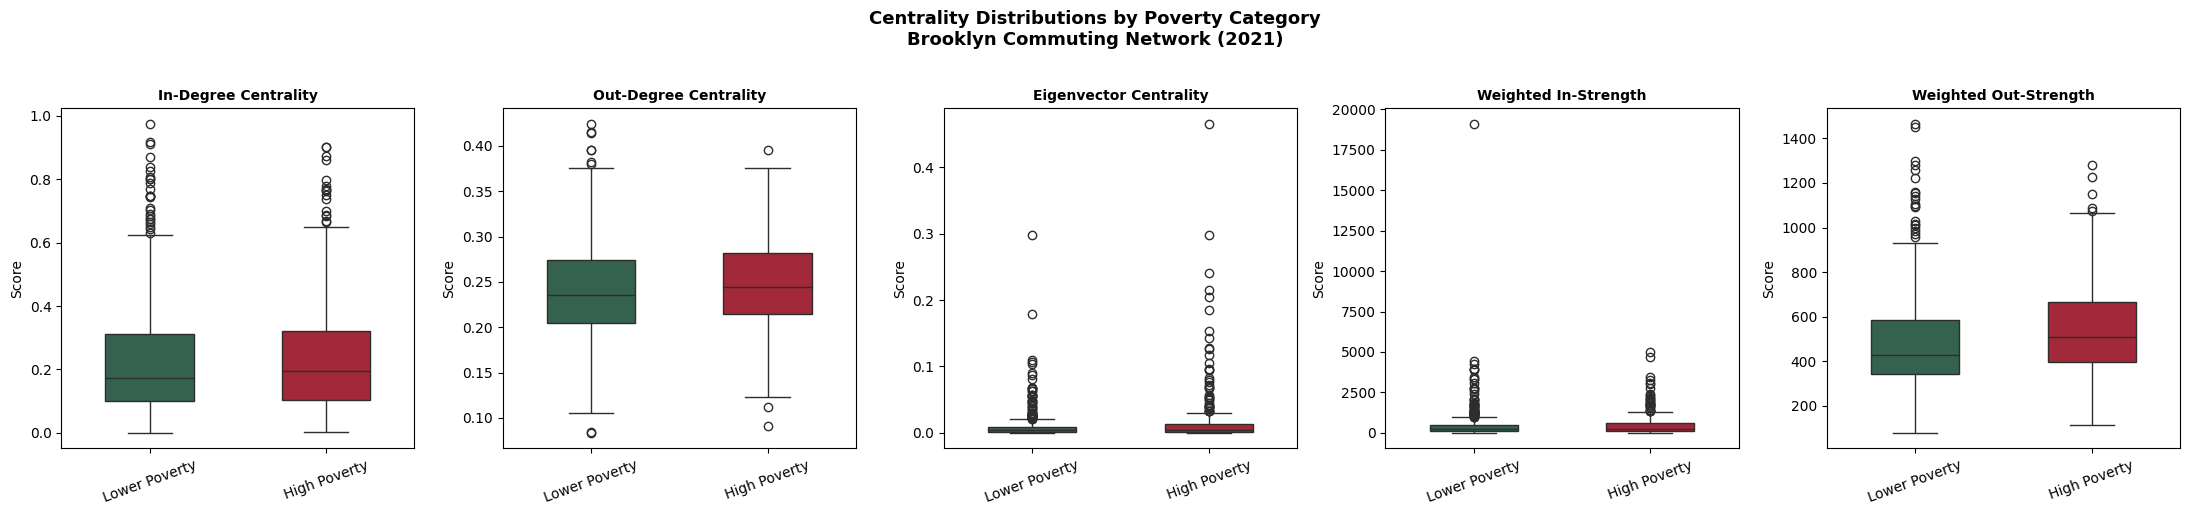

In [13]:
plot_df = node_df[node_df['poverty_category'].isin(['High Poverty', 'Lower Poverty'])].copy()
palette = {'High Poverty': '#B5152B', 'Lower Poverty': '#2D6A4F'}

plot_metrics = [
    ('in_degree_centrality',  'In-Degree Centrality'),
    ('out_degree_centrality', 'Out-Degree Centrality'),
    ('eigenvector_centrality','Eigenvector Centrality'),
    ('in_strength',           'Weighted In-Strength'),
    ('out_strength',          'Weighted Out-Strength'),
]

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
fig.suptitle('Centrality Distributions by Poverty Category\nBrooklyn Commuting Network (2021)',
             fontsize=13, fontweight='bold', y=1.02)

for (col, title), ax in zip(plot_metrics, axes):
    sns.boxplot(data=plot_df, x='poverty_category', y=col,
                palette=palette, ax=ax, width=0.5)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('Score')
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('centrality_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

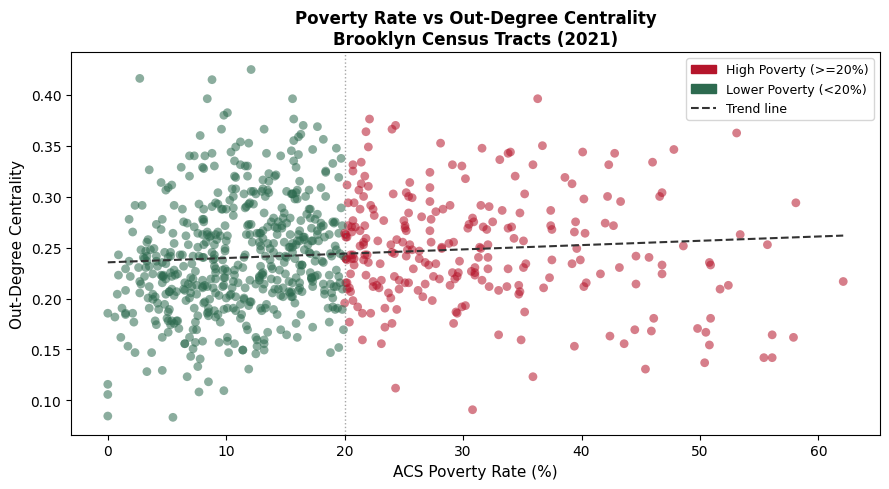

Trend line slope: 0.000422 per 1% increase in poverty rate


In [14]:
scatter_df = node_df[node_df['poverty_category'].isin(['High Poverty', 'Lower Poverty'])].dropna(
    subset=['poverty_rate', 'out_degree_centrality'])

fig, ax = plt.subplots(figsize=(9, 5))
color_map_scatter = {'High Poverty': '#B5152B', 'Lower Poverty': '#2D6A4F'}
colors = scatter_df['poverty_category'].map(color_map_scatter)

ax.scatter(scatter_df['poverty_rate'], scatter_df['out_degree_centrality'],
           c=colors, alpha=0.55, s=40, edgecolors='none')

m, b = np.polyfit(scatter_df['poverty_rate'], scatter_df['out_degree_centrality'], 1)
x_line = np.linspace(scatter_df['poverty_rate'].min(), scatter_df['poverty_rate'].max(), 100)
ax.plot(x_line, m * x_line + b, color='#333333', linewidth=1.5, linestyle='--')
ax.axvline(x=20, color='gray', linewidth=1, linestyle=':', alpha=0.7)

legend_handles = [
    mpatches.Patch(color='#B5152B', label='High Poverty (>=20%)'),
    mpatches.Patch(color='#2D6A4F', label='Lower Poverty (<20%)'),
    plt.Line2D([0],[0], color='#333333', linestyle='--', label='Trend line'),
]
ax.legend(handles=legend_handles, fontsize=9)
ax.set_xlabel('ACS Poverty Rate (%)', fontsize=11)
ax.set_ylabel('Out-Degree Centrality', fontsize=11)
ax.set_title('Poverty Rate vs Out-Degree Centrality\nBrooklyn Census Tracts (2021)', fontweight='bold')

plt.tight_layout()
plt.savefig('poverty_vs_out_degree_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Trend line slope: {m:.6f} per 1% increase in poverty rate')

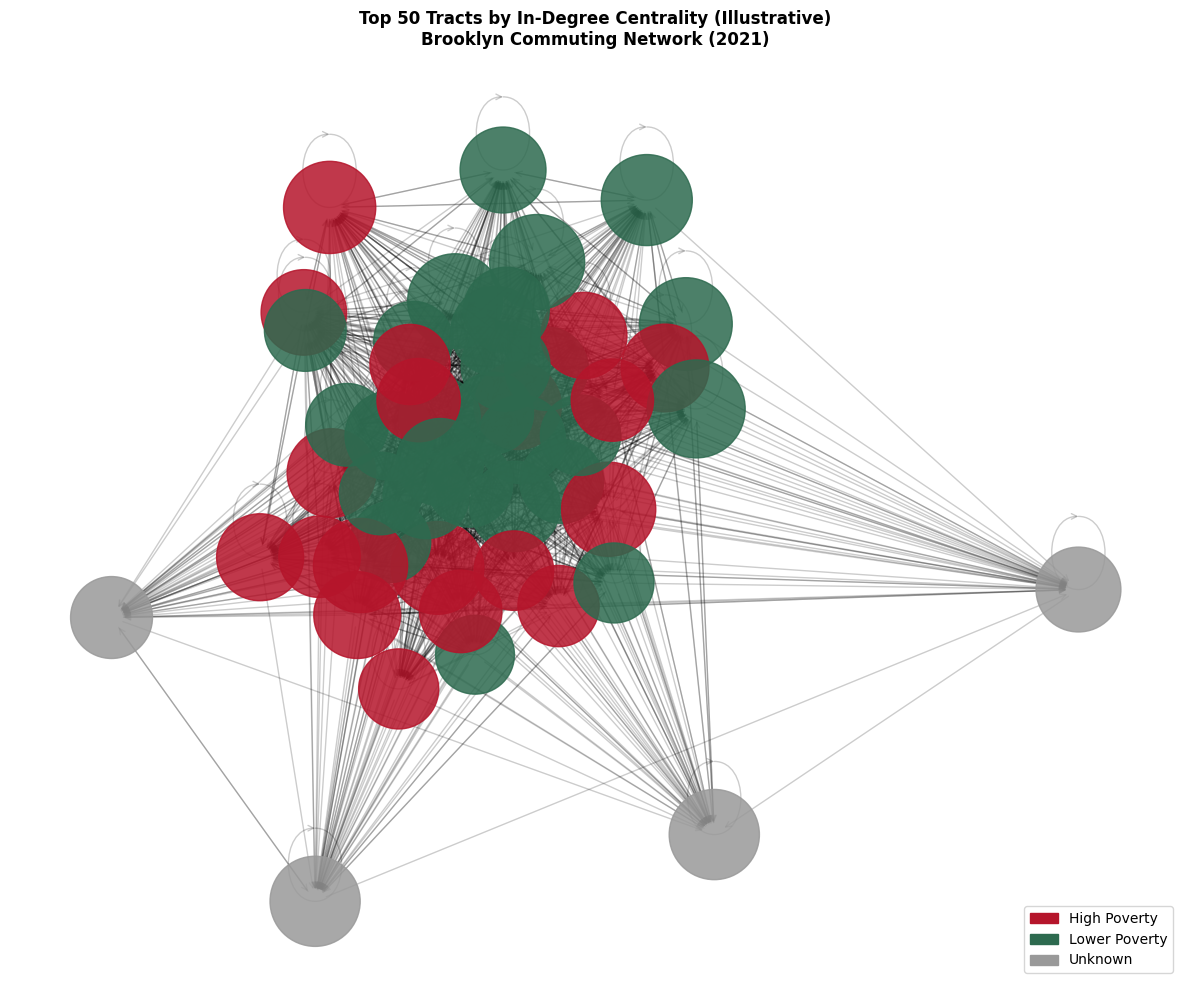

Node labels are 11-digit FIPS codes. Geographic interpretation requires a tract-name crosswalk.


In [15]:
top50 = sorted(in_deg, key=in_deg.get, reverse=True)[:50]
G_sub = G.subgraph(top50).copy()

color_map_net = {'High Poverty': '#B5152B', 'Lower Poverty': '#2D6A4F', 'Unknown': '#999999'}
node_colors = [color_map_net.get(G.nodes[n].get('poverty_category', 'Unknown'), '#999999')
               for n in G_sub.nodes()]
node_sizes = [in_deg.get(n, 0.001) * 5000 + 100 for n in G_sub.nodes()]

fig, ax = plt.subplots(figsize=(12, 10))
pos = nx.spring_layout(G_sub, seed=42, k=0.5)
nx.draw_networkx_nodes(G_sub, pos, node_color=node_colors, node_size=node_sizes, alpha=0.85, ax=ax)
nx.draw_networkx_edges(G_sub, pos, alpha=0.2, arrows=True,
                       arrowstyle='->', arrowsize=10, ax=ax)

legend_handles = [
    mpatches.Patch(color='#B5152B', label='High Poverty'),
    mpatches.Patch(color='#2D6A4F', label='Lower Poverty'),
    mpatches.Patch(color='#999999', label='Unknown')
]
ax.legend(handles=legend_handles, loc='lower right', fontsize=10)
ax.set_title('Top 50 Tracts by In-Degree Centrality (Illustrative)\nBrooklyn Commuting Network (2021)',
             fontsize=12, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('network_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print('Node labels are 11-digit FIPS codes. Geographic interpretation requires a tract-name crosswalk.')

In [16]:
# IMPORTANT: The commuting network is defined at the census tract level.
# Neighborhood results here are a DESCRIPTIVE SUMMARY of tract-level centrality
# aggregated to NTAs -- not a separate neighborhood-level network analysis.
# Averaging may smooth over strong tract-level variation within a single NTA.
# Each NTA = multiple census tracts; we average centrality and poverty rate per NTA
# majority_poverty = the more common category among tracts in the NTA

nbhd_df = (
    node_df[node_df['neighborhood'] != 'Unknown']
    .groupby('neighborhood')
    .agg(
        tract_count=('tract', 'count'),
        avg_poverty_rate=('poverty_rate', 'mean'),
        avg_in_degree=('in_degree_centrality', 'mean'),
        avg_out_degree=('out_degree_centrality', 'mean'),
        avg_evc=('eigenvector_centrality', 'mean'),
        avg_in_strength=('in_strength', 'mean'),
        avg_out_strength=('out_strength', 'mean'),
    )
    .reset_index()
)

# Majority poverty category per neighborhood
def majority_cat(group):
    cats = group[group['poverty_category'].isin(['High Poverty', 'Lower Poverty'])]['poverty_category']
    if len(cats) == 0:
        return 'Unknown'
    return cats.value_counts().idxmax()

cat_map = node_df.groupby('neighborhood').apply(majority_cat).reset_index()
cat_map.columns = ['neighborhood', 'majority_poverty']
nbhd_df = nbhd_df.merge(cat_map, on='neighborhood')

# Round for display
nbhd_df['avg_poverty_rate'] = nbhd_df['avg_poverty_rate'].round(1)
nbhd_df['avg_in_degree']    = nbhd_df['avg_in_degree'].round(4)
nbhd_df['avg_out_degree']   = nbhd_df['avg_out_degree'].round(4)
nbhd_df['avg_evc']          = nbhd_df['avg_evc'].round(4)
nbhd_df['avg_in_strength']  = nbhd_df['avg_in_strength'].round(0).astype('Int64')

print(f'Brooklyn neighborhoods in network: {len(nbhd_df)}')
print()
print('=== All Brooklyn Neighborhoods: Centrality and Poverty (sorted by in-degree) ===')
display_nbhd = nbhd_df.sort_values('avg_in_degree', ascending=False).reset_index(drop=True)
display_nbhd.index += 1
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 160)
print(display_nbhd[['neighborhood', 'majority_poverty', 'avg_poverty_rate',
                     'avg_in_degree', 'avg_out_degree', 'avg_evc',
                     'avg_in_strength', 'tract_count']].to_string())

Brooklyn neighborhoods in network: 69

=== All Brooklyn Neighborhoods: Centrality and Poverty (sorted by in-degree) ===
                                      neighborhood majority_poverty  avg_poverty_rate  avg_in_degree  avg_out_degree  avg_evc  avg_in_strength  tract_count
1              Downtown Brooklyn-DUMBO-Boerum Hill    Lower Poverty              14.9         0.5778          0.1668   0.0534             3051           11
2                               Brooklyn Navy Yard          Unknown               NaN         0.5729          0.0660   0.0554             1179            1
3                                     Borough Park     High Poverty              31.4         0.4679          0.2260   0.0610             1270           21
4                                     Williamsburg    Lower Poverty              15.7         0.4389          0.1962   0.0570             1121           13
5                               Sunset Park (West)    Lower Poverty              17.0         0.4376

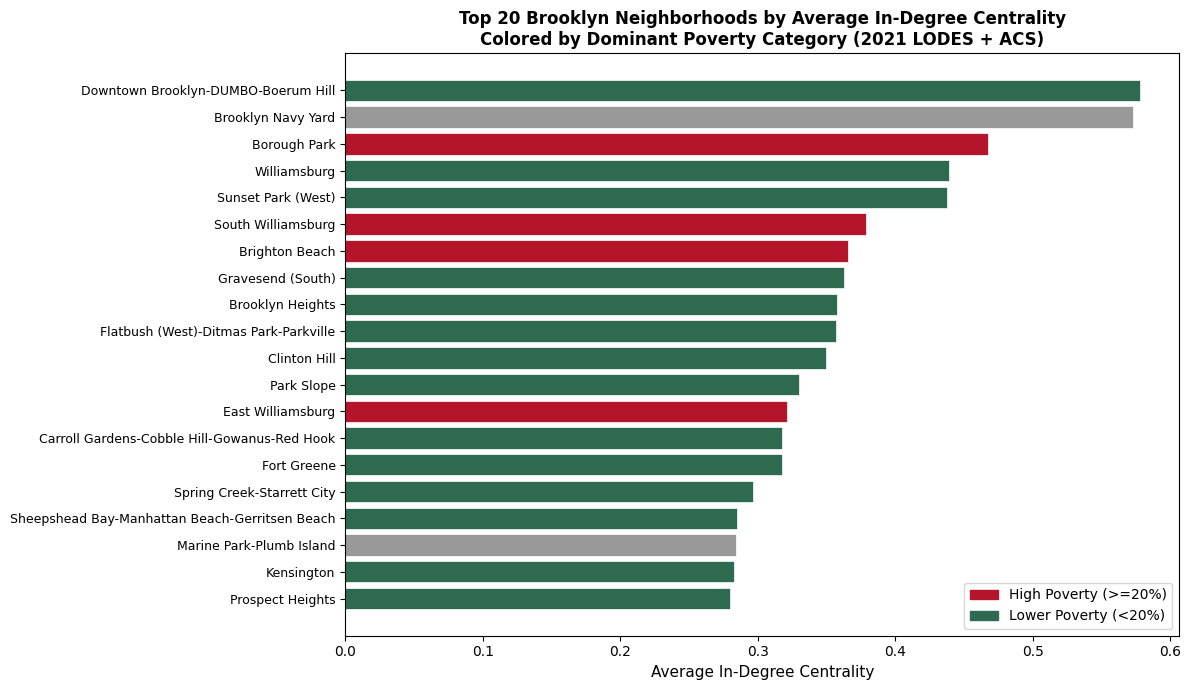

Saved: top20_neighborhoods_indegree.png


In [17]:
# Bars colored by majority poverty category; shows hub neighborhoods and their poverty status

top20_nbhd = nbhd_df.sort_values('avg_in_degree', ascending=False).head(20)

bar_palette = {'High Poverty': '#B5152B', 'Lower Poverty': '#2D6A4F', 'Unknown': '#999999'}
bar_colors = [bar_palette.get(c, '#999999') for c in top20_nbhd['majority_poverty']]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top20_nbhd['neighborhood'][::-1], top20_nbhd['avg_in_degree'][::-1],
               color=bar_colors[::-1], edgecolor='white', linewidth=0.5)

legend_handles = [
    mpatches.Patch(color='#B5152B', label='High Poverty (>=20%)'),
    mpatches.Patch(color='#2D6A4F', label='Lower Poverty (<20%)'),
]
ax.legend(handles=legend_handles, loc='lower right', fontsize=10)
ax.set_xlabel('Average In-Degree Centrality', fontsize=11)
ax.set_title('Top 20 Brooklyn Neighborhoods by Average In-Degree Centrality\n'
             'Colored by Dominant Poverty Category (2021 LODES + ACS)',
             fontsize=12, fontweight='bold')
ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig('top20_neighborhoods_indegree.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: top20_neighborhoods_indegree.png')

In [18]:
metrics = [
    ('in_degree_centrality',  'In-Degree Centrality'),
    ('out_degree_centrality', 'Out-Degree Centrality'),
    ('eigenvector_centrality','Eigenvector Centrality'),
    ('in_strength',           'Weighted In-Strength'),
    ('out_strength',          'Weighted Out-Strength'),
]


for col, label in metrics:
    print(f'\n=== Top 10 Tracts by {label} ===')
    top10 = (node_df[node_df['poverty_category'].isin(['High Poverty', 'Lower Poverty'])]
             .nlargest(10, col)
             [['neighborhood', 'tract', col, 'poverty_category', 'poverty_rate']]
             .reset_index(drop=True))
    top10.index += 1
    top10['poverty_rate'] = top10['poverty_rate'].round(1)
    if col in ['in_degree_centrality', 'out_degree_centrality', 'eigenvector_centrality']:
        top10[col] = top10[col].round(4)
    else:
        top10[col] = top10[col].astype(int)
    print(top10.to_string())


=== Top 10 Tracts by In-Degree Centrality ===
                              neighborhood        tract  in_degree_centrality poverty_category  poverty_rate
1      Downtown Brooklyn-DUMBO-Boerum Hill  36047001100                0.9751    Lower Poverty           8.5
2                         Brooklyn Heights  36047000900                0.9166    Lower Poverty           1.2
3      Downtown Brooklyn-DUMBO-Boerum Hill  36047003700                0.9116    Lower Poverty           9.0
4   Sunset Park (East)-Borough Park (West)  36047011400                0.9004     High Poverty          31.3
5                             Williamsburg  36047054900                0.9004     High Poverty          24.0
6                       Sunset Park (West)  36047002200                0.8717     High Poverty          25.7
7      Downtown Brooklyn-DUMBO-Boerum Hill  36047002100                0.8705    Lower Poverty           4.3
8        Prospect Lefferts Gardens-Wingate  36047080800                0.8618    

In [19]:

high_mean_indeg   = high['in_degree_centrality'].mean()
lower_mean_indeg  = lower['in_degree_centrality'].mean()
high_mean_outdeg  = high['out_degree_centrality'].mean()
lower_mean_outdeg = lower['out_degree_centrality'].mean()
high_mean_evc     = high['eigenvector_centrality'].dropna().mean()
lower_mean_evc    = lower['eigenvector_centrality'].dropna().mean()
high_mean_instrength  = high['in_strength'].mean()
lower_mean_instrength = lower['in_strength'].mean()
high_mean_outstrength  = high['out_strength'].mean()
lower_mean_outstrength = lower['out_strength'].mean()

print('=== PROJECT 1 SUMMARY ===')
print()
print('NETWORK')
print(f'  Nodes:             {G.number_of_nodes()} census tracts (Kings County, NY)')
print(f'  Edges:             {G.number_of_edges()} directed tract-to-tract flows')
print(f'  Graph density:     {nx.density(G):.4f}')
print(f'  Total commuters:   {total_weight:,.0f}')
print()
print('HYPOTHESIS (stated)')
print('  Lower-poverty tracts would show higher in-degree and eigenvector centrality.')
print('  High-poverty tracts would be more peripheral.')
print()
print('CENTRALITY RESULTS (unweighted -- breadth of connections)')
print(f'  In-degree   -- High Poverty: {high_mean_indeg:.4f}  | Lower Poverty: {lower_mean_indeg:.4f}')
print(f'  Out-degree  -- High Poverty: {high_mean_outdeg:.4f}  | Lower Poverty: {lower_mean_outdeg:.4f}')
print(f'  EVC         -- High Poverty: {high_mean_evc:.4f}  | Lower Poverty: {lower_mean_evc:.4f}')
print()
print('STRENGTH RESULTS (weighted -- commuter volume)')
print(f'  In-strength  -- High Poverty: {high_mean_instrength:,.0f}  | Lower Poverty: {lower_mean_instrength:,.0f}')
print(f'  Out-strength -- High Poverty: {high_mean_outstrength:,.0f}  | Lower Poverty: {lower_mean_outstrength:,.0f}')
print()
print('  Weighted in/out-strength measures commuter volume rather than connection breadth.')
print('  They allow us to test whether poverty groups differ not just in how many tracts')
print('  they connect to, but in how many total commuters actually flow through them.')
print('  See Mann-Whitney U test above for significance of all five measures.')
print()
print('INTERPRETATION')
print()
print('  The hypothesis was not supported. High-poverty tracts were not significantly')
print('  more peripheral in the Brooklyn internal commuting network by in-degree or')
print('  eigenvector centrality. Mean values were slightly higher among high-poverty')
print('  tracts on both measures, but differences did not reach significance.')
print()
print('  The only statistically significant centrality difference was out-degree centrality, suggesting')
print('  that poverty groups differ more in how broadly residents connect to work destinations')
print('  than in whether their tracts function as inbound job hubs.')
if results.get('out_strength', {}).get('sig') == 'YES':
    print('  Weighted out-strength also reached significance, suggesting the difference appears in both connection breadth and commuter volume.')
else:
    print('  Weighted out-strength did not reach significance, suggesting the difference is more visible in connection breadth than in commuter volume.')
print()
print('  The high graph density reflects broadly distributed internal commuting across')
print('  Brooklyn, which compresses centrality scores and may reduce statistical power.')
print()
print('SCOPE NOTE')
print('  Scoped to Brooklyn-internal commuting only. Tracts near borough boundaries')
print('  may appear less central than they functionally are, as cross-borough flows')
print('  (e.g., to Manhattan) are excluded by design.')


=== PROJECT 1 SUMMARY ===

NETWORK
  Nodes:             804 census tracts (Kings County, NY)
  Edges:             153190 directed tract-to-tract flows
  Graph density:     0.2373
  Total commuters:   396,195

HYPOTHESIS (stated)
  Lower-poverty tracts would show higher in-degree and eigenvector centrality.
  High-poverty tracts would be more peripheral.

CENTRALITY RESULTS (unweighted -- breadth of connections)
  In-degree   -- High Poverty: 0.2468  | Lower Poverty: 0.2331
  Out-degree  -- High Poverty: 0.2484  | Lower Poverty: 0.2402
  EVC         -- High Poverty: 0.0204  | Lower Poverty: 0.0102

STRENGTH RESULTS (weighted -- commuter volume)
  In-strength  -- High Poverty: 528  | Lower Poverty: 476
  Out-strength -- High Poverty: 549  | Lower Poverty: 488

  Weighted in/out-strength measures commuter volume rather than connection breadth.
  They allow us to test whether poverty groups differ not just in how many tracts
  they connect to, but in how many total commuters actually flow 